# <span style='color:Red'>Misbinding models (Part 1)</span>

## <span style='color:Red'>Libraries, functions, paths</span>

In [1]:
import sys, os
from pathlib import Path

currentWD = os.path.dirname(Path.cwd())
if currentWD not in sys.path:
    sys.path.append(currentWD)
#print(sys.path)

import numpy, pandas, re, ast, seaborn, jlib, sklearn, pickle
from matplotlib import pyplot

saveFigs = True
imagePath = 'img/models/'
imageFormat = 'svg'
exportsPathBase = 'exports/'
exportsPath = 'exports/biasModels/'
exportsPathTemp = 'exports/biasModels/temp/partial/'

desiredEffectSize = 'ges'

metricToCalculate = 'NormLL'

numpy.random.seed(1)

if not os.path.exists(imagePath):
    os.makedirs(imagePath)

if not os.path.exists(exportsPath):
    os.makedirs(exportsPath)

if not os.path.exists(exportsPathTemp):
    os.makedirs(exportsPathTemp)

mapValueHandler = jlib.data.mapValueHandler.MapValueHandler(exportsPathBase+"exp4Values.csv")

allParticipantData = pandas.read_csv(exportsPathBase+'participantData_long.csv')
allParticipantData.drop(['Mouse X path','Mouse Y path','Target'],axis=1,inplace=True)

## <span style='color:Red'>Fit functions for all participants</span>

In [2]:
allBaseFits = {'MBSK':[],'MBDK':[],'NMB':[],'Bias':[]}
allBaseLL = {'MBSK':[],'MBDK':[],'NMB':[],'Bias':[]}

for participant in numpy.unique(allParticipantData['Subject']):
    participantData = allParticipantData[allParticipantData['Subject']==participant]

    allErrors = participantData['Response error'].to_numpy()*numpy.pi/180
    allTargets = numpy.zeros(allErrors.shape)
    allMeanErrors = participantData['Continuous target'].to_numpy()-participantData['Mean target'].to_numpy()
    allMeanErrors = allMeanErrors*2*numpy.pi/jlib.compression.constants.EXP4_RESPONSE_SECTIONS

    # Misbinding with single, shared kappa
    params,logLikelihood,_ = jlib.analysis.models.fitMisbindingMultiVonMises(allErrors,allTargets,allMeanErrors[:,None])
    allBaseFits['MBSK'].append(params)
    allBaseLL['MBSK'].append(logLikelihood)
    # Misbinding with separate kappas
    params,logLikelihood,_ = jlib.analysis.models.fitMisbindingMultiVonMises(allErrors,allTargets,allMeanErrors[:,None],separateKappas=True)
    allBaseFits['MBDK'].append(params)
    allBaseLL['MBDK'].append(logLikelihood)
    # No misbinding
    params,logLikelihood,_ = jlib.analysis.models.fitMisbindingMultiVonMises(allErrors,allTargets)
    allBaseFits['NMB'].append(params)
    allBaseLL['NMB'].append(logLikelihood)
    # Biased model
    params = jlib.analysis.models.fitBiasedModel(allErrors,-allMeanErrors,[1,0.5,0.1],
                                                 ((1e-6,numpy.inf),(-1,1),(0,1)))
    logLikelihood = jlib.analysis.models._biasedNLL(params.x,allErrors,-allMeanErrors)
    params = {'kappa':params.x[0],'bias':params.x[1],'guessingP':params.x[2]}
    allBaseFits['Bias'].append(params)
    allBaseLL['Bias'].append(-logLikelihood)

In [3]:
allBaseLL['Bias']

[-503.14969607779403,
 -392.7453834983685,
 -644.0026289212559,
 -677.069252740273,
 -423.1572872520385,
 -629.542072012786,
 -708.6504822619949,
 -711.006599339591,
 -653.8409042782802,
 -345.8339869818408,
 -410.087561429365,
 -474.65085806670737,
 -628.5298010027841,
 -518.9903395487828,
 -461.9045395844168,
 -313.51334561208057,
 -490.0111351747283,
 -558.7723699466328,
 -440.0275214579427,
 -433.1669179447487,
 -771.0083469380941,
 -521.4575621697912,
 -206.43651229627773,
 -837.1285251942229]

### <span style='color:Red'>Display results</span>

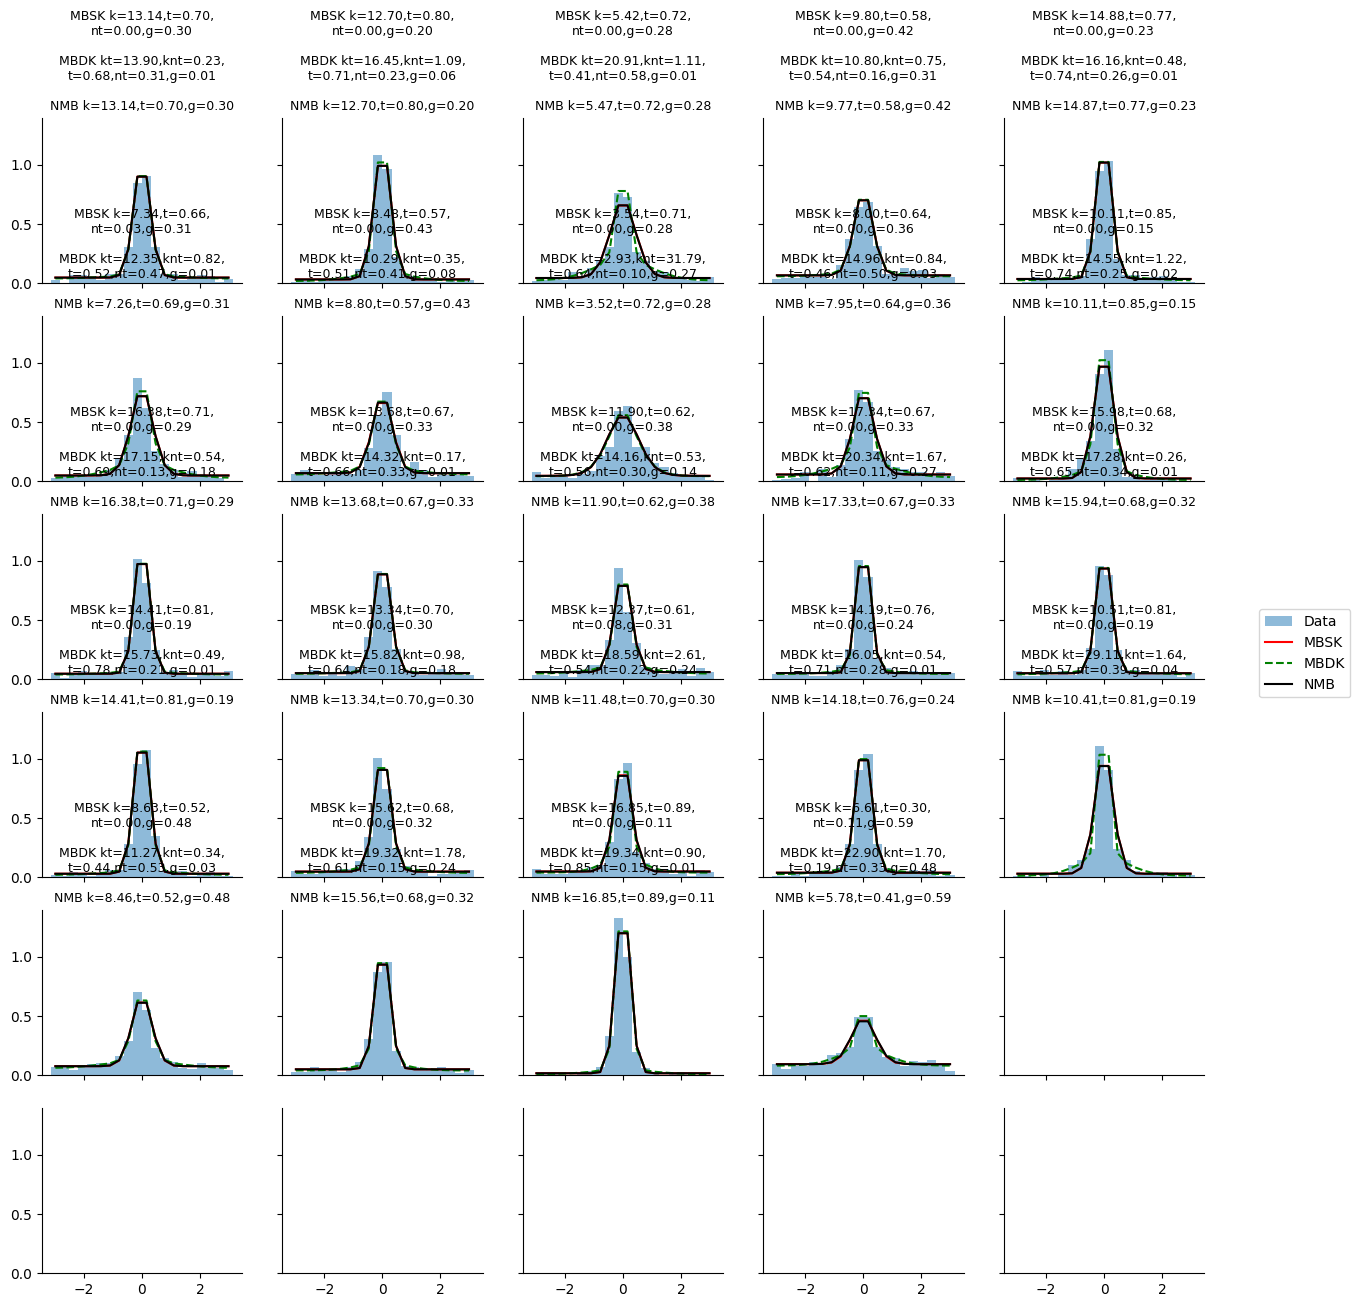

In [4]:
import matplotlib.pyplot as plt
from scipy.stats import vonmises

fig,ax = plt.subplots(6,5,figsize=(15,15),sharex=True,sharey=True)
participantIndex = 0

for participant in numpy.unique(allParticipantData['Subject']):
    participantData = allParticipantData[allParticipantData['Subject']==participant]
    
    hist,binEdges = numpy.histogram(participantData['Response error']*numpy.pi/180,
                                    bins=20,range=(-numpy.pi, numpy.pi),density=True)
    binCenters = (binEdges[:-1]+binEdges[1:])/2

    axX = participantIndex%5
    axY = numpy.int64(numpy.floor(participantIndex/5))

    labels = ["","","","",""]
    if (participantIndex==0):
        labels = ["Data","MBSK","MBDK",'NMB','Bias']
    ax[axY,axX].hist(participantData['Response error']*numpy.pi/180,bins=20,range=(-numpy.pi, numpy.pi),
                     density=True,alpha=0.5,label=labels[0])
    
    potentialMeans = numpy.linspace(-numpy.pi/9,numpy.pi/9,20)
    
    # MBSK
    MBSKFit = allBaseFits['MBSK'][participantIndex]
    pdf = MBSKFit['targetP']*vonmises.pdf(binCenters,MBSKFit['kappaT'],loc=0)+MBSKFit['guessingP']/(2*numpy.pi)
    pdfNT = [vonmises.pdf(binCenters,MBSKFit['kappaT'],loc=d) for d in potentialMeans]
    pdf += MBSKFit['nonTargetP']*numpy.mean(pdfNT,axis=0)

    ax[axY,axX].plot(binCenters,pdf,'r-',label=labels[1])

    # MBDK
    MBDKFit = allBaseFits['MBDK'][participantIndex]
    pdf = MBDKFit['targetP']*vonmises.pdf(binCenters,MBDKFit['kappaT'],loc=0)+MBDKFit['guessingP']/(2*numpy.pi)
    pdfNT = [vonmises.pdf(binCenters,MBDKFit['kappaNT'],loc=d) for d in potentialMeans]
    pdf += MBDKFit['nonTargetP']*numpy.mean(pdfNT,axis=0)

    ax[axY,axX].plot(binCenters,pdf,'g--',label=labels[2])

    # NMB
    NMBFit = allBaseFits['NMB'][participantIndex]
    pdf = NMBFit['targetP']*vonmises.pdf(binCenters,NMBFit['kappaT'],loc=0)+NMBFit['guessingP']/(2*numpy.pi)

    ax[axY,axX].plot(binCenters,pdf,'k-',label=labels[3])

    # Bias
    # BiasFit = allBaseFits['Bias'][participantIndex]
    # pdf = (1-BiasFit['guessingP'])*vonmises.pdf(binCenters,)

    # ax[axY,axX].plot(binCenters,pdf,'m--',label=labels[4])

    # ax[axY,axX].plot(binCenters,
    #                  vonmises.pdf(binCenters,vonmisesFit[0],loc=vonmisesFit[1]),
    #                  'g-',label=labels[2])

    participantIndex += 1

    title = f'MBSK k={MBSKFit["kappaT"]:.2f},t={MBSKFit["targetP"]:.2f},\nnt={MBSKFit["nonTargetP"]:.2f},g={MBSKFit["guessingP"]:.2f}'
    title += f'\n\nMBDK kt={MBDKFit["kappaT"]:.2f},knt={MBDKFit["kappaNT"]:.2f},\nt={MBDKFit["targetP"]:.2f},nt={MBDKFit["nonTargetP"]:.2f},g={MBDKFit["guessingP"]:.2f}'
    title += f'\n\nNMB k={NMBFit["kappaT"]:.2f},t={NMBFit["targetP"]:.2f},g={NMBFit["guessingP"]:.2f}'

    ax[axY,axX].set_title(title,fontsize=9)

seaborn.despine()
fig.legend(loc="center right")

## <span style='color:Red'>Fit all trials together</span>

In [5]:
if not os.path.exists(exportsPathTemp+'allFits.pkl'):
    allFits,allLL = jlib.analysis.models.fitAllBiasModelsCV(allParticipantData,'all',metricToCalculate,nFolds=10,nJobs=5)
    with open(exportsPathTemp+'allFits.pkl','wb') as fp:
        pickle.dump(allFits,fp)
    with open(exportsPathTemp+'allLL.pkl','wb') as fp:
        pickle.dump(allLL,fp)
else:
    with open(exportsPathTemp+'allFits.pkl','rb') as fp:
        allFits = pickle.load(fp)
    with open(exportsPathTemp+'allLL.pkl','rb') as fp:
        allLL = pickle.load(fp)

In [6]:
finalLLTrain = {'MBSK_all':[],'MBDK_all':[],'Bias_all':[],'NMB_all':[]}
finalLLTest = {'MBSK_all':[],'MBDK_all':[],'Bias_all':[],'NMB_all':[]}

for participant in numpy.unique(allParticipantData['Subject']):
    a = numpy.array(allLL['MBSK'][participant])
    b = numpy.array(allLL['MBDK'][participant])
    c = numpy.array(allLL['NMB'][participant])
    d = numpy.array(allLL['Bias'][participant])

    finalLLTrain['MBSK_all'].append(numpy.sum(a,axis=0)[0])
    finalLLTrain['MBDK_all'].append(numpy.sum(b,axis=0)[0])
    finalLLTrain['NMB_all'].append(numpy.sum(c,axis=0)[0])
    finalLLTrain['Bias_all'].append(numpy.sum(d,axis=0)[0])

    finalLLTest['MBSK_all'].append(numpy.sum(a,axis=0)[1])
    finalLLTest['MBDK_all'].append(numpy.sum(b,axis=0)[1])
    finalLLTest['NMB_all'].append(numpy.sum(c,axis=0)[1])
    finalLLTest['Bias_all'].append(numpy.sum(d,axis=0)[1])

numpy.sum(finalLLTrain['MBSK_all']),numpy.sum(finalLLTrain['MBDK_all']),numpy.sum(finalLLTrain['NMB_all']),numpy.sum(finalLLTrain['Bias_all'])

(-257.62425458499456,
 -255.2669388124242,
 -257.6618213602777,
 -246.31866071209114)

In [7]:
numpy.sum(finalLLTest['MBSK_all']),numpy.sum(finalLLTest['MBDK_all']),numpy.sum(finalLLTest['NMB_all']),numpy.sum(finalLLTest['Bias_all'])

(-258.96073375114884,
 -257.0055031504553,
 -258.913091296198,
 -248.15450932232628)

In [8]:
allFits['Bias']

{400: [{'kappa': 22.106512474314385,
   'bias': 0.772978738687051,
   'guessingP': 0.30928615277105925},
  {'kappa': 21.7340314759593,
   'bias': 0.8322799420734122,
   'guessingP': 0.3092917350581982},
  {'kappa': 22.437392702125614,
   'bias': 0.8065385203073311,
   'guessingP': 0.31851767660606467},
  {'kappa': 20.38508062275619,
   'bias': 0.8179024296337094,
   'guessingP': 0.30005679664755097},
  {'kappa': 20.652137507710844,
   'bias': 0.7853679551494557,
   'guessingP': 0.30888321454546197},
  {'kappa': 20.322174137377974,
   'bias': 0.7818764840822694,
   'guessingP': 0.3236727979564928},
  {'kappa': 20.926780044539814,
   'bias': 0.821208593273013,
   'guessingP': 0.333760968614279},
  {'kappa': 21.797266900157624,
   'bias': 0.8473954662898223,
   'guessingP': 0.31797582017013526},
  {'kappa': 22.772388611110056,
   'bias': 0.7976875395033991,
   'guessingP': 0.32311633414450724},
  {'kappa': 21.002717503912198,
   'bias': 0.7848575261161767,
   'guessingP': 0.31495954832234

## <span style='color:Red'>Fit chunking vs non-chunking trials</span>

In [9]:
chunkingData = allParticipantData.copy()
chunkingData.drop(chunkingData[chunkingData['Trial type']=='Non-chunkable'].index,axis=0,inplace=True)
nonChunkingData = allParticipantData.copy()
nonChunkingData.drop(nonChunkingData[nonChunkingData['Trial type']=='Chunkable'].index,axis=0,inplace=True)

if not os.path.exists(exportsPathTemp+'allFitsChunking.pkl'):
    allFitsChunking,allLLChunking = jlib.analysis.models.fitAllBiasModelsCV(chunkingData,'all',metricToCalculate,nFolds=10,nJobs=5)
    with open(exportsPathTemp+'allFitsChunking.pkl','wb') as fp:
        pickle.dump(allFitsChunking,fp)
    with open(exportsPathTemp+'allLLChunking.pkl','wb') as fp:
        pickle.dump(allLLChunking,fp)
    
    allFitsNonChunking,allLLNonChunking = jlib.analysis.models.fitAllBiasModelsCV(nonChunkingData,'all',metricToCalculate,nFolds=10,nJobs=5)
    with open(exportsPathTemp+'allFitsNonChunking.pkl','wb') as fp:
        pickle.dump(allFitsNonChunking,fp)
    with open(exportsPathTemp+'allLLNonChunking.pkl','wb') as fp:
        pickle.dump(allLLNonChunking,fp)
else:
    with open(exportsPathTemp+'allFitsChunking.pkl','rb') as fp:
        allFitsChunking = pickle.load(fp)
    with open(exportsPathTemp+'allLLChunking.pkl','rb') as fp:
        allLLChunking = pickle.load(fp)
    with open(exportsPathTemp+'allFitsNonChunking.pkl','rb') as fp:
        allFitsNonChunking = pickle.load(fp)
    with open(exportsPathTemp+'allLLNonChunking.pkl','rb') as fp:
        allLLNonChunking = pickle.load(fp)

In [10]:
propsToAdd = ['MBSK_C_all','MBDK_C_all','Bias_C_all','NMB_C_all',
              'MBSK_NC_all','MBDK_NC_all','Bias_NC_all','NMB_NC_all']
for prop in propsToAdd:
    finalLLTrain[prop] = []
    finalLLTest[prop] = []

for participant in numpy.unique(allParticipantData['Subject']):
    a = numpy.array(allLLChunking['MBSK'][participant])
    b = numpy.array(allLLChunking['MBDK'][participant])
    c = numpy.array(allLLChunking['NMB'][participant])
    d = numpy.array(allLLChunking['Bias'][participant])

    finalLLTrain['MBSK_C_all'].append(numpy.sum(a,axis=0)[0])
    finalLLTrain['MBDK_C_all'].append(numpy.sum(b,axis=0)[0])
    finalLLTrain['NMB_C_all'].append(numpy.sum(c,axis=0)[0])
    finalLLTrain['Bias_C_all'].append(numpy.sum(d,axis=0)[0])

    finalLLTest['MBSK_C_all'].append(numpy.sum(a,axis=0)[1])
    finalLLTest['MBDK_C_all'].append(numpy.sum(b,axis=0)[1])
    finalLLTest['NMB_C_all'].append(numpy.sum(c,axis=0)[1])
    finalLLTest['Bias_C_all'].append(numpy.sum(d,axis=0)[1])

    a = numpy.array(allLLNonChunking['MBSK'][participant])
    b = numpy.array(allLLNonChunking['MBDK'][participant])
    c = numpy.array(allLLNonChunking['NMB'][participant])
    d = numpy.array(allLLNonChunking['Bias'][participant])

    finalLLTrain['MBSK_NC_all'].append(numpy.sum(a,axis=0)[0])
    finalLLTrain['MBDK_NC_all'].append(numpy.sum(b,axis=0)[0])
    finalLLTrain['NMB_NC_all'].append(numpy.sum(c,axis=0)[0])
    finalLLTrain['Bias_NC_all'].append(numpy.sum(d,axis=0)[0])

    finalLLTest['MBSK_NC_all'].append(numpy.sum(a,axis=0)[1])
    finalLLTest['MBDK_NC_all'].append(numpy.sum(b,axis=0)[1])
    finalLLTest['NMB_NC_all'].append(numpy.sum(c,axis=0)[1])
    finalLLTest['Bias_NC_all'].append(numpy.sum(d,axis=0)[1])

[numpy.sum(finalLLTrain['MBSK_C_all']),numpy.sum(finalLLTrain['MBDK_C_all']),
 numpy.sum(finalLLTrain['NMB_C_all']),numpy.sum(finalLLTrain['Bias_C_all'])]

[-224.40344812042278,
 -222.23841784842963,
 -224.41719163037078,
 -207.71717172055784]

In [11]:
[numpy.sum(finalLLTest['MBSK_C_all']),numpy.sum(finalLLTest['MBDK_C_all']),
 numpy.sum(finalLLTest['NMB_C_all']),numpy.sum(finalLLTest['Bias_C_all'])]

[-226.2206563906855,
 -224.7766201308173,
 -226.14936540902846,
 -210.4368044888064]

In [12]:
[numpy.sum(finalLLTrain['MBSK_NC_all']),numpy.sum(finalLLTrain['MBDK_NC_all']),
 numpy.sum(finalLLTrain['NMB_NC_all']),numpy.sum(finalLLTrain['Bias_NC_all'])]

[-314.44379209553335,
 -310.8709710104467,
 -314.77035418362294,
 -310.4138665588075]

In [13]:
[numpy.sum(finalLLTest['MBSK_NC_all']),numpy.sum(finalLLTest['MBDK_NC_all']),
 numpy.sum(finalLLTest['NMB_NC_all']),numpy.sum(finalLLTest['Bias_NC_all'])]

[-319.3833445303163,
 -317.350821518642,
 -319.33874278080094,
 -317.36567204096497]

In [14]:
allFitsChunking['Bias']

{400: [{'kappa': 22.410161020165525,
   'bias': 0.8887821681445077,
   'guessingP': 0.19334151429829693},
  {'kappa': 21.92008858440374,
   'bias': 0.8369999260294289,
   'guessingP': 0.2230167916932048},
  {'kappa': 21.20894409893353,
   'bias': 0.8877076950810753,
   'guessingP': 0.19523665869827697},
  {'kappa': 23.373867804781163,
   'bias': 0.9256242747724557,
   'guessingP': 0.20332715750083383},
  {'kappa': 22.41604237763781,
   'bias': 0.8849286368973375,
   'guessingP': 0.21185287312488177},
  {'kappa': 21.883951469466208,
   'bias': 0.8569786284012343,
   'guessingP': 0.20721321371278187},
  {'kappa': 22.034690676138194,
   'bias': 0.9426527129083384,
   'guessingP': 0.187326487266595},
  {'kappa': 23.197493093997785,
   'bias': 0.8864515649203485,
   'guessingP': 0.19836982041893164},
  {'kappa': 21.709328106276825,
   'bias': 0.8547904107481606,
   'guessingP': 0.2195064901914952},
  {'kappa': 22.201526078199752,
   'bias': 0.8790714969110662,
   'guessingP': 0.203538365022

## <span style='color:Red'>Fit chunking vs non-chunking good trials (makes no sense to do)</span>

In [15]:
# chunkingGData = chunkingData.copy()
# chunkingGData.drop(chunkingGData[chunkingGData['Response error (absolute)']<40].index,axis=0,inplace=True)
# nonChunkingGData = nonChunkingData.copy()
# nonChunkingGData.drop(nonChunkingGData[nonChunkingGData['Response error (absolute)']<40].index,axis=0,inplace=True)

# allFitsChunkingG,allLLChunkingG = jlib.analysis.models.fitAllBiasModelsCV(chunkingGData,'all','LL',nFolds=10,nJobs=5)
# allFitsNonChunkingG,allLLNonChunkingG = jlib.analysis.models.fitAllBiasModelsCV(nonChunkingGData,'all','LL',nFolds=10,nJobs=5)

## <span style='color:Red'>Fit chunking vs non-chunking = f(cue)</span>

In [16]:
chunkingIData = chunkingData.copy()
chunkingIData.drop(chunkingIData[chunkingIData['Cue type']=='Uninformative'].index,axis=0,inplace=True)
chunkingUData = chunkingData.copy()
chunkingUData.drop(chunkingUData[chunkingUData['Cue type']=='Informative'].index,axis=0,inplace=True)

nonChunkingIData = nonChunkingData.copy()
nonChunkingIData.drop(nonChunkingIData[nonChunkingIData['Cue type']=='Uninformative'].index,axis=0,inplace=True)
nonChunkingUData = nonChunkingData.copy()
nonChunkingUData.drop(nonChunkingUData[nonChunkingUData['Cue type']=='Informative'].index,axis=0,inplace=True)

if not os.path.exists(exportsPathTemp+'allFitsChunkingI.pkl'):
    allFitsChunkingI,allLLChunkingI = jlib.analysis.models.fitAllBiasModelsCV(chunkingIData,'all',metricToCalculate,nFolds=10,nJobs=5)
    with open(exportsPathTemp+'allFitsChunkingI.pkl','wb') as fp:
        pickle.dump(allFitsChunkingI,fp)
    with open(exportsPathTemp+'allLLChunkingI.pkl','wb') as fp:
        pickle.dump(allLLChunkingI,fp)

    allFitsChunkingU,allLLChunkingU = jlib.analysis.models.fitAllBiasModelsCV(chunkingUData,'all',metricToCalculate,nFolds=10,nJobs=5)
    with open(exportsPathTemp+'allFitsChunkingU.pkl','wb') as fp:
        pickle.dump(allFitsChunkingU,fp)
    with open(exportsPathTemp+'allLLChunkingU.pkl','wb') as fp:
        pickle.dump(allLLChunkingU,fp)

    allFitsNonChunkingI,allLLNonChunkingI = jlib.analysis.models.fitAllBiasModelsCV(nonChunkingIData,'all',metricToCalculate,nFolds=10,nJobs=5)
    with open(exportsPathTemp+'allFitsNonChunkingI.pkl','wb') as fp:
        pickle.dump(allFitsNonChunkingI,fp)
    with open(exportsPathTemp+'allLLNonChunkingI.pkl','wb') as fp:
        pickle.dump(allLLNonChunkingI,fp)

    allFitsNonChunkingU,allLLNonChunkingU = jlib.analysis.models.fitAllBiasModelsCV(nonChunkingUData,'all',metricToCalculate,nFolds=10,nJobs=5)
    with open(exportsPathTemp+'allFitsNonChunkingU.pkl','wb') as fp:
        pickle.dump(allFitsNonChunkingU,fp)
    with open(exportsPathTemp+'allLLNonChunkingU.pkl','wb') as fp:
        pickle.dump(allLLNonChunkingU,fp)
else:
    with open(exportsPathTemp+'allFitsChunkingI.pkl','rb') as fp:
        allFitsChunkingI = pickle.load(fp)
    with open(exportsPathTemp+'allLLChunkingI.pkl','rb') as fp:
        allLLChunkingI = pickle.load(fp)
    with open(exportsPathTemp+'allFitsChunkingU.pkl','rb') as fp:
        allFitsChunkingU = pickle.load(fp)
    with open(exportsPathTemp+'allLLChunkingU.pkl','rb') as fp:
        allLLChunkingU = pickle.load(fp)
    with open(exportsPathTemp+'allFitsNonChunkingI.pkl','rb') as fp:
        allFitsNonChunkingI = pickle.load(fp)
    with open(exportsPathTemp+'allLLNonChunkingI.pkl','rb') as fp:
        allLLNonChunkingI = pickle.load(fp)
    with open(exportsPathTemp+'allFitsNonChunkingU.pkl','rb') as fp:
        allFitsNonChunkingU = pickle.load(fp)
    with open(exportsPathTemp+'allLLNonChunkingU.pkl','rb') as fp:
        allLLNonChunkingU = pickle.load(fp)

In [17]:
propsToAdd = ['MBSK_C_I','MBDK_C_I','Bias_C_I','NMB_C_I',
              'MBSK_C_U','MBDK_C_U','Bias_C_U','NMB_C_U',
              'MBSK_NC_I','MBDK_NC_I','Bias_NC_I','NMB_NC_I',
              'MBSK_NC_U','MBDK_NC_U','Bias_NC_U','NMB_NC_U']
for prop in propsToAdd:
    finalLLTrain[prop] = []
    finalLLTest[prop] = []

for participant in numpy.unique(allParticipantData['Subject']):
    a = numpy.array(allLLChunkingI['MBSK'][participant])
    b = numpy.array(allLLChunkingI['MBDK'][participant])
    c = numpy.array(allLLChunkingI['NMB'][participant])
    d = numpy.array(allLLChunkingI['Bias'][participant])

    finalLLTrain['MBSK_C_I'].append(numpy.sum(a,axis=0)[0])
    finalLLTrain['MBDK_C_I'].append(numpy.sum(b,axis=0)[0])
    finalLLTrain['NMB_C_I'].append(numpy.sum(c,axis=0)[0])
    finalLLTrain['Bias_C_I'].append(numpy.sum(d,axis=0)[0])

    finalLLTest['MBSK_C_I'].append(numpy.sum(a,axis=0)[1])
    finalLLTest['MBDK_C_I'].append(numpy.sum(b,axis=0)[1])
    finalLLTest['NMB_C_I'].append(numpy.sum(c,axis=0)[1])
    finalLLTest['Bias_C_I'].append(numpy.sum(d,axis=0)[1])

    a = numpy.array(allLLChunkingU['MBSK'][participant])
    b = numpy.array(allLLChunkingU['MBDK'][participant])
    c = numpy.array(allLLChunkingU['NMB'][participant])
    d = numpy.array(allLLChunkingU['Bias'][participant])

    finalLLTrain['MBSK_C_U'].append(numpy.sum(a,axis=0)[0])
    finalLLTrain['MBDK_C_U'].append(numpy.sum(b,axis=0)[0])
    finalLLTrain['NMB_C_U'].append(numpy.sum(c,axis=0)[0])
    finalLLTrain['Bias_C_U'].append(numpy.sum(d,axis=0)[0])

    finalLLTest['MBSK_C_U'].append(numpy.sum(a,axis=0)[1])
    finalLLTest['MBDK_C_U'].append(numpy.sum(b,axis=0)[1])
    finalLLTest['NMB_C_U'].append(numpy.sum(c,axis=0)[1])
    finalLLTest['Bias_C_U'].append(numpy.sum(d,axis=0)[1])

    a = numpy.array(allLLNonChunkingI['MBSK'][participant])
    b = numpy.array(allLLNonChunkingI['MBDK'][participant])
    c = numpy.array(allLLNonChunkingI['NMB'][participant])
    d = numpy.array(allLLNonChunkingI['Bias'][participant])

    finalLLTrain['MBSK_NC_I'].append(numpy.sum(a,axis=0)[0])
    finalLLTrain['MBDK_NC_I'].append(numpy.sum(b,axis=0)[0])
    finalLLTrain['NMB_NC_I'].append(numpy.sum(c,axis=0)[0])
    finalLLTrain['Bias_NC_I'].append(numpy.sum(d,axis=0)[0])

    finalLLTest['MBSK_NC_I'].append(numpy.sum(a,axis=0)[1])
    finalLLTest['MBDK_NC_I'].append(numpy.sum(b,axis=0)[1])
    finalLLTest['NMB_NC_I'].append(numpy.sum(c,axis=0)[1])
    finalLLTest['Bias_NC_I'].append(numpy.sum(d,axis=0)[1])

    a = numpy.array(allLLNonChunkingU['MBSK'][participant])
    b = numpy.array(allLLNonChunkingU['MBDK'][participant])
    c = numpy.array(allLLNonChunkingU['NMB'][participant])
    d = numpy.array(allLLNonChunkingU['Bias'][participant])

    finalLLTrain['MBSK_NC_U'].append(numpy.sum(a,axis=0)[0])
    finalLLTrain['MBDK_NC_U'].append(numpy.sum(b,axis=0)[0])
    finalLLTrain['NMB_NC_U'].append(numpy.sum(c,axis=0)[0])
    finalLLTrain['Bias_NC_U'].append(numpy.sum(d,axis=0)[0])

    finalLLTest['MBSK_NC_U'].append(numpy.sum(a,axis=0)[1])
    finalLLTest['MBDK_NC_U'].append(numpy.sum(b,axis=0)[1])
    finalLLTest['NMB_NC_U'].append(numpy.sum(c,axis=0)[1])
    finalLLTest['Bias_NC_U'].append(numpy.sum(d,axis=0)[1])

[numpy.sum(finalLLTrain['MBSK_C_I']),numpy.sum(finalLLTrain['MBDK_C_I']),
 numpy.sum(finalLLTrain['NMB_C_I']),numpy.sum(finalLLTrain['Bias_C_I'])]

[-194.79680745985218,
 -192.67085939287966,
 -194.85010562357945,
 -178.26128730273786]

In [18]:
[numpy.sum(finalLLTest['MBSK_C_I']),numpy.sum(finalLLTest['MBDK_C_I']),
 numpy.sum(finalLLTest['NMB_C_I']),numpy.sum(finalLLTest['Bias_C_I'])]

[-199.87652009190555,
 -198.29864429807859,
 -198.7739094554894,
 -185.58890373822442]

In [19]:
allFitsChunkingI['Bias']

{400: [{'kappa': 20.566424405663863,
   'bias': 0.8397300954694207,
   'guessingP': 0.1538353323679442},
  {'kappa': 19.14545993072088,
   'bias': 0.8999614264537623,
   'guessingP': 0.15866865439228017},
  {'kappa': 22.435351068124476,
   'bias': 0.8484286701387346,
   'guessingP': 0.15741797926270737},
  {'kappa': 21.27522680148201,
   'bias': 0.8297381945466535,
   'guessingP': 0.150127686360159},
  {'kappa': 19.862760489919527,
   'bias': 0.9147411158544279,
   'guessingP': 0.16118061690489388},
  {'kappa': 22.349646444256265,
   'bias': 0.840768961338671,
   'guessingP': 0.16825595431645252},
  {'kappa': 24.14308793531755,
   'bias': 0.8284937909616916,
   'guessingP': 0.1746330527345188},
  {'kappa': 23.26870075135623,
   'bias': 0.8933254781319071,
   'guessingP': 0.17665226739709852},
  {'kappa': 22.601403762376332,
   'bias': 0.8821942554215437,
   'guessingP': 0.1679238801861716},
  {'kappa': 22.76344610294383,
   'bias': 0.879068959675506,
   'guessingP': 0.16033745421352194

In [20]:
[numpy.sum(finalLLTrain['MBSK_C_U']),numpy.sum(finalLLTrain['MBDK_C_U']),
 numpy.sum(finalLLTrain['NMB_C_U']),numpy.sum(finalLLTrain['Bias_C_U'])]

[-248.15644678770687,
 -245.4091078078096,
 -248.1664266970621,
 -230.13740849833277]

In [21]:
[numpy.sum(finalLLTest['MBSK_C_U']),numpy.sum(finalLLTest['MBDK_C_U']),
 numpy.sum(finalLLTest['NMB_C_U']),numpy.sum(finalLLTest['Bias_C_U'])]

[-251.226312008142, -250.6051516732335, -251.048457224337, -235.03037687472838]

In [22]:
allFitsChunkingU['Bias']

{400: [{'kappa': 21.58929691346198,
   'bias': 0.911297993243064,
   'guessingP': 0.244508290619938},
  {'kappa': 23.99200554609758,
   'bias': 0.926519227257056,
   'guessingP': 0.24924067190612714},
  {'kappa': 22.279072755426714,
   'bias': 0.8842597072040677,
   'guessingP': 0.2107317155413833},
  {'kappa': 22.114915751534653,
   'bias': 0.938287598537473,
   'guessingP': 0.26464767101812814},
  {'kappa': 22.42295499438453,
   'bias': 0.9075753043817677,
   'guessingP': 0.24288051316155465},
  {'kappa': 22.249796238759107,
   'bias': 0.8769535067200995,
   'guessingP': 0.24806801112534355},
  {'kappa': 23.030131370669142,
   'bias': 0.9466595470003558,
   'guessingP': 0.24867298900079088},
  {'kappa': 22.61512730730549,
   'bias': 0.8864272727424541,
   'guessingP': 0.24706320908512408},
  {'kappa': 22.95290676080295,
   'bias': 0.905403645520426,
   'guessingP': 0.23499833422695973},
  {'kappa': 22.764737633171414,
   'bias': 0.944829510284913,
   'guessingP': 0.24816408947529087}

In [23]:
[numpy.sum(finalLLTrain['MBSK_NC_I']),numpy.sum(finalLLTrain['MBDK_NC_I']),
 numpy.sum(finalLLTrain['NMB_NC_I']),numpy.sum(finalLLTrain['Bias_NC_I'])]

[-287.30457450664676,
 -281.3033038875127,
 -287.7498706778893,
 -283.341940072816]

In [24]:
[numpy.sum(finalLLTest['MBSK_NC_I']),numpy.sum(finalLLTest['MBDK_NC_I']),
 numpy.sum(finalLLTest['NMB_NC_I']),numpy.sum(finalLLTest['Bias_NC_I'])]

[-299.3177396113805,
 -294.4508804068199,
 -297.6788325085636,
 -297.80816434857763]

In [25]:
allFitsNonChunkingI['Bias']

{400: [{'kappa': 13.29684329587565,
   'bias': 0.5186445860876949,
   'guessingP': 0.45448950004369876},
  {'kappa': 12.641049292931578,
   'bias': 0.5506462840336088,
   'guessingP': 0.4540812943208835},
  {'kappa': 11.162138124596114,
   'bias': 0.4637255351109875,
   'guessingP': 0.4488720578671728},
  {'kappa': 13.781868884261025,
   'bias': 0.5623558213059027,
   'guessingP': 0.4657673691802864},
  {'kappa': 19.617660957766137,
   'bias': 0.6318477344449951,
   'guessingP': 0.47043090771290463},
  {'kappa': 16.15470734826082,
   'bias': 0.7185765398967079,
   'guessingP': 0.47642730047622656},
  {'kappa': 13.847785931092716,
   'bias': 0.6749545338311808,
   'guessingP': 0.436564786961662},
  {'kappa': 10.82214487026252,
   'bias': 0.5363583179128826,
   'guessingP': 0.4094893983894776},
  {'kappa': 4.92297486196658,
   'bias': 0.4386693625033282,
   'guessingP': 0.33191705423209494},
  {'kappa': 12.538275795219935,
   'bias': 0.6045405118068397,
   'guessingP': 0.4586417530889416

In [26]:
[numpy.sum(finalLLTrain['MBSK_NC_U']),numpy.sum(finalLLTrain['MBDK_NC_U']),
 numpy.sum(finalLLTrain['NMB_NC_U']),numpy.sum(finalLLTrain['Bias_NC_U'])]

[-333.68848049447865,
 -331.36917997637585,
 -334.3274124908817,
 -328.51259577313823]

In [27]:
[numpy.sum(finalLLTest['MBSK_NC_U']),numpy.sum(finalLLTest['MBDK_NC_U']),
 numpy.sum(finalLLTest['NMB_NC_U']),numpy.sum(finalLLTest['Bias_NC_U'])]

[-343.9158385549255,
 -344.78526117327374,
 -343.6780884703023,
 -342.49534399641254]

In [28]:
allFitsNonChunkingU['Bias']

{400: [{'kappa': 25.569317636042395,
   'bias': 0.617357536037405,
   'guessingP': 0.5514226326126468},
  {'kappa': 28.217391393025917,
   'bias': 0.7215315180637928,
   'guessingP': 0.6135151546532801},
  {'kappa': 30.200000978805157,
   'bias': 0.6469430789424714,
   'guessingP': 0.6261298056339939},
  {'kappa': 29.36640689269814,
   'bias': 0.5760321178605476,
   'guessingP': 0.5952276171396178},
  {'kappa': 28.63908845481715,
   'bias': 0.7276130398024049,
   'guessingP': 0.6232904415719219},
  {'kappa': 24.889958777644118,
   'bias': 0.6316692477053848,
   'guessingP': 0.5808806763514706},
  {'kappa': 35.71941358048564,
   'bias': 0.8045710889965849,
   'guessingP': 0.5985901650364222},
  {'kappa': 21.251602522628833,
   'bias': 0.4472342902061557,
   'guessingP': 0.5823701793921917},
  {'kappa': 22.78596429792111,
   'bias': 0.4774720293662207,
   'guessingP': 0.6158113275754844},
  {'kappa': 28.18132409807352,
   'bias': 0.7679884520450982,
   'guessingP': 0.6108845090648135}],


In [29]:
finalLLTrain['Subject'] = numpy.unique(allParticipantData['Subject'])
finalLLTest['Subject'] = numpy.unique(allParticipantData['Subject'])

finalLLTrainDF = pandas.DataFrame.from_dict(finalLLTrain)
finalLLTestDF = pandas.DataFrame.from_dict(finalLLTest)

finalLLTrainDF.to_csv(exportsPath+"modelsTrainLL.csv")
finalLLTestDF.to_csv(exportsPath+"modelsTestLL.csv")

In [30]:
finalLLTestDF

,MBSK_all,MBDK_all,Bias_all,NMB_all,MBSK_C_all,MBDK_C_all,Bias_C_all,NMB_C_all,MBSK_NC_all,MBDK_NC_all,...,NMB_C_U,MBSK_NC_I,MBDK_NC_I,Bias_NC_I,NMB_NC_I,MBSK_NC_U,MBDK_NC_U,Bias_NC_U,NMB_NC_U,Subject
0,-10.470127,-10.462056,-9.423846,-10.470208,-7.998033,-7.981981,-6.430839,-7.998600,-14.481809,-14.493642,...,-9.073592,-13.767937,-13.817659,-13.891606,-13.764432,-15.077030,-15.076516,-15.082692,-15.076653,400
1,-8.281678,-8.170048,-7.633826,-8.280531,-6.068106,-5.927368,-5.239565,-6.069184,-12.580412,-12.549666,...,-7.609874,-13.781188,-13.261337,-12.771953,-13.763328,-12.001356,-12.324076,-12.097967,-11.995895,401
2,-12.481527,-12.066528,-12.478978,-12.477868,-12.024711,-11.623757,-12.038371,-12.023226,-13.688190,-13.213008,...,-14.697056,-12.404976,-12.107582,-11.860239,-12.407785,-14.612632,-14.471775,-14.626308,-14.671227,403
3,-13.391802,-13.407339,-13.265088,-13.391840,-13.088253,-13.089374,-12.842747,-13.088413,-14.234681,-14.430946,...,-12.880216,-14.504307,-14.860893,-14.530484,-14.626599,-13.915226,-14.007326,-13.643114,-13.912758,404
4,-8.394476,-8.363565,-8.217994,-8.394680,-7.197383,-7.105027,-6.881068,-7.197279,-10.776727,-10.831437,...,-7.684240,-8.556173,-8.460016,-8.582942,-8.540741,-12.981003,-13.180132,-12.993822,-12.981348,405
5,-12.250474,-12.133805,-12.258445,-12.232475,-11.851075,-11.653389,-11.857633,-11.847615,-13.090113,-13.277559,...,-13.239770,-12.712144,-12.758832,-12.781959,-12.619586,-14.186424,-14.047940,-14.088191,-14.036597,406
6,-13.818632,-13.854122,-13.751989,-13.816227,-13.092278,-13.119352,-13.058939,-13.092106,-15.372381,-15.400146,...,-14.507341,-15.199146,-15.243637,-15.269688,-15.201142,-15.749476,-15.863332,-15.392602,-15.747882,407
7,-13.947079,-13.919871,-13.977723,-13.949005,-12.884446,-12.856542,-12.873601,-12.884031,-15.778381,-15.814585,...,-14.034157,-15.420244,-15.600319,-15.472756,-15.362231,-17.128111,-17.176323,-17.119467,-17.115060,408
8,-12.832498,-12.705284,-12.846330,-12.827424,-11.310403,-11.090597,-11.322270,-11.307602,-15.455446,-15.521474,...,-12.148199,-14.330152,-14.516239,-14.552433,-14.329991,-16.742560,-16.933537,-16.892285,-16.686513,409
9,-7.688246,-7.515531,-6.721035,-7.688731,-5.744530,-5.746546,-4.486033,-5.744257,-11.704259,-10.676373,...,-7.200597,-10.447994,-10.251927,-11.142272,-10.442960,-13.068531,-11.832961,-12.551156,-13.062502,412


## <span style='color:Red'>ANOVA on testing LLs</span>

### <span style='color:Red'>Fits on all data</span>

In [31]:
allDataModelDF = pandas.DataFrame({'Subject':numpy.unique(finalLLTestDF['Subject']),
                                   'MBSKTestLL':finalLLTestDF['MBSK_all'],
                                   'MBDKTestLL':finalLLTestDF['MBDK_all'],
                                   'NMBTestLL':finalLLTestDF['NMB_all'],
                                   'BiasTestLL':finalLLTestDF['Bias_all']})

# allDataANOVA = jlib.analysis.anova.anovaRM(rPath='C:/Program Files/R/R-4.4.1/',
#                                            data=allDataModelDF,
#                                            rmLabels=['Model'],
#                                            rmLists=[['MBSK','MBDK','NMB','Bias']],
#                                            rmMeasureName='TestLL',
#                                            rmTerms='~Model',
#                                            sphericityTest=True,
#                                            effectSize=[desiredEffectSize])

# allDataANOVA['within'].columns = allDataANOVA['within'].columns.str.rstrip('[none]')

allDataANOVA = jlib.analysis.anova.anovaRMNP(rPath='C:/Program Files/R/R-4.4.1/',
                        data=allDataModelDF,
                        measurements=['MBSKTestLL','MBDKTestLL','NMBTestLL','BiasTestLL'])

mapValueHandler.setKeyValue("anovaModelFitsAll",
                            jlib.data.constants.extractFriedmanResults(allDataANOVA['within'],
                                                                       allDataModelDF.shape[0],4))

allDataANOVA

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: package 'jmv' was built under R version 4.4.3 



{'within':       stat   df         p
 "1"  21.75  3.0  0.000074}

In [32]:
allDataTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                      variables=[allDataModelDF['MBSKTestLL']-allDataModelDF['MBDKTestLL'],
                                                                 allDataModelDF['MBSKTestLL']-allDataModelDF['NMBTestLL'],
                                                                 allDataModelDF['MBSKTestLL']-allDataModelDF['BiasTestLL'],
                                                                 allDataModelDF['MBDKTestLL']-allDataModelDF['NMBTestLL'],
                                                                 allDataModelDF['MBDKTestLL']-allDataModelDF['BiasTestLL'],
                                                                 allDataModelDF['NMBTestLL']-allDataModelDF['BiasTestLL']],
                                                      testValue=0,isStudent=False,isWilcoxon=True,hypothesis='dt',
                                                      effectSize=True,descriptives=True)

allDataTtestOS['ttest'].columns = allDataTtestOS['ttest'].columns.str.rstrip('[wilc]')

mapValueHandler.setKeyValue("ttestOSAllTrialDiffMBDK-MBSK",
                            jlib.data.constants.extractWilcoxonResults(allDataTtestOS['ttest'],0,6))

mapValueHandler.setKeyValue("ttestOSAllTrialDiffNMB-MBSK",
                            jlib.data.constants.extractWilcoxonResults(allDataTtestOS['ttest'],1,6))

mapValueHandler.setKeyValue("ttestOSAllTrialDiffBias-MBSK",
                            jlib.data.constants.extractWilcoxonResults(allDataTtestOS['ttest'],2,6))

mapValueHandler.setKeyValue("ttestOSAllTrialDiffNMB-MBDK",
                            jlib.data.constants.extractWilcoxonResults(allDataTtestOS['ttest'],3,6))

mapValueHandler.setKeyValue("ttestOSAllTrialDiffBias-MBDK",
                            jlib.data.constants.extractWilcoxonResults(allDataTtestOS['ttest'],4,6))

mapValueHandler.setKeyValue("ttestOSAllTrialDiffBias-NMB",
                            jlib.data.constants.extractWilcoxonResults(allDataTtestOS['ttest'],5,6))

allDataTtestOS

{'ttest':          var        name   stat         p                     esType        es
 "set0"  set0  Wilcoxon W   25.0  0.000108  Rank biserial correlation -0.833333
 "set1"  set1  Wilcoxon W  147.0  0.944107  Rank biserial correlation -0.020000
 "set2"  set2  Wilcoxon W   20.0  0.000044  Rank biserial correlation -0.866667
 "set3"  set3  Wilcoxon W  275.0  0.000108  Rank biserial correlation  0.833333
 "set4"  set4  Wilcoxon W   62.0  0.010508  Rank biserial correlation -0.586667
 "set5"  set5  Wilcoxon W   23.0  0.000076  Rank biserial correlation -0.846667,
 'normality':         name         w         p
 "set0"  set0  0.714582  0.000016
 "set1"  set1  0.679486  0.000005
 "set2"  set2  0.816085  0.000546
 "set3"  set3  0.702708  0.000011
 "set4"  set4  0.906286  0.029320
 "set5"  set5  0.820201  0.000642,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   24 -0.081468 -0.039014  0.125559  0.025630
 "set1"  set1   24 -0.001985  0.000077  0.00

### <span style='color:Red'>Fits on chunking data</span>

In [33]:
chunkingDataModelDF = pandas.DataFrame({'Subject':numpy.unique(finalLLTestDF['Subject']),
                                        'MBSKTestLL':finalLLTestDF['MBSK_C_all'],
                                        'MBDKTestLL':finalLLTestDF['MBDK_C_all'],
                                        'NMBTestLL':finalLLTestDF['NMB_C_all'],
                                        'BiasTestLL':finalLLTestDF['Bias_C_all']})

# chunkingDataANOVA = jlib.analysis.anova.anovaRM(rPath='C:/Program Files/R/R-4.4.1/',
#                                                 data=chunkingDataModelDF,
#                                                 rmLabels=['Model'],
#                                                 rmLists=[['MBSK','MBDK','NMB','Bias']],
#                                                 rmMeasureName='TestLL',
#                                                 rmTerms='~Model',
#                                                 sphericityTest=True,
#                                                 effectSize=[desiredEffectSize])

# chunkingDataANOVA['within'].columns = chunkingDataANOVA['within'].columns.str.rstrip('[none]')

chunkingDataANOVA = jlib.analysis.anova.anovaRMNP(rPath='C:/Program Files/R/R-4.4.1/',
                                                  data=chunkingDataModelDF,
                                                  measurements=['MBSKTestLL','MBDKTestLL','NMBTestLL','BiasTestLL'])

mapValueHandler.setKeyValue("anovaModelFitsChunking",
                            jlib.data.constants.extractFriedmanResults(chunkingDataANOVA['within'],
                                                                       allDataModelDF.shape[0],4))

chunkingDataANOVA

{'within':       stat   df         p
 "1"  13.55  3.0  0.003586}

In [34]:
variablesToTest = [chunkingDataModelDF['MBDKTestLL']-chunkingDataModelDF['MBSKTestLL'],
                   chunkingDataModelDF['NMBTestLL']-chunkingDataModelDF['MBSKTestLL'],
                   chunkingDataModelDF['BiasTestLL']-chunkingDataModelDF['MBSKTestLL'],
                   chunkingDataModelDF['NMBTestLL']-chunkingDataModelDF['MBDKTestLL'],
                   chunkingDataModelDF['BiasTestLL']-chunkingDataModelDF['MBDKTestLL'],
                   chunkingDataModelDF['BiasTestLL']-chunkingDataModelDF['NMBTestLL']]

chunkingDataTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           variables=variablesToTest,
                                                           testValue=0,isStudent=False,isWilcoxon=True,hypothesis='dt',
                                                           effectSize=True,descriptives=True)

chunkingDataTtestOS['ttest'].columns = chunkingDataTtestOS['ttest'].columns.str.rstrip('[wilc]')

mapValueHandler.setKeyValue("ttestOSCTrialDiffMBDK-MBSK",
                            jlib.data.constants.extractWilcoxonResults(chunkingDataTtestOS['ttest'],0,6))

mapValueHandler.setKeyValue("ttestOSCTrialDiffNMB-MBSK",
                            jlib.data.constants.extractWilcoxonResults(chunkingDataTtestOS['ttest'],1,6))

mapValueHandler.setKeyValue("ttestOSCTrialDiffBias-MBSK",
                            jlib.data.constants.extractWilcoxonResults(chunkingDataTtestOS['ttest'],2,6))

mapValueHandler.setKeyValue("ttestOSCTrialDiffNMB-MBDK",
                            jlib.data.constants.extractWilcoxonResults(chunkingDataTtestOS['ttest'],3,6))

mapValueHandler.setKeyValue("ttestOSCTrialDiffBias-MBDK",
                            jlib.data.constants.extractWilcoxonResults(chunkingDataTtestOS['ttest'],4,6))

mapValueHandler.setKeyValue("ttestOSCTrialDiffBias-NMB",
                            jlib.data.constants.extractWilcoxonResults(chunkingDataTtestOS['ttest'],5,6))

chunkingDataTtestOS

{'ttest':          var        name   stat         p                     esType        es
 "set0"  set0  Wilcoxon W  214.0  0.069102  Rank biserial correlation  0.426667
 "set1"  set1  Wilcoxon W  193.0  0.229190  Rank biserial correlation  0.286667
 "set2"  set2  Wilcoxon W  282.0  0.000030  Rank biserial correlation  0.880000
 "set3"  set3  Wilcoxon W   95.0  0.120840  Rank biserial correlation -0.366667
 "set4"  set4  Wilcoxon W  246.0  0.004811  Rank biserial correlation  0.640000
 "set5"  set5  Wilcoxon W  279.0  0.000053  Rank biserial correlation  0.860000,
 'normality':         name         w             p
 "set0"  set0  0.787686  1.865671e-04
 "set1"  set1  0.368555  3.718428e-09
 "set2"  set2  0.797021  2.634421e-04
 "set3"  set3  0.770287  1.000140e-04
 "set4"  set4  0.869378  5.115347e-03
 "set5"  set5  0.803851  3.407525e-04,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   24  0.060168  0.019394  0.129457  0.026425
 "set1"  set1   

### <span style='color:Red'>Fits on non-chunking data</span>

In [35]:
nonChunkingDataModelDF = pandas.DataFrame({'Subject':numpy.unique(finalLLTestDF['Subject']),
                                           'MBSKTestLL':finalLLTestDF['MBSK_NC_all'],
                                           'MBDKTestLL':finalLLTestDF['MBDK_NC_all'],
                                           'NMBTestLL':finalLLTestDF['NMB_NC_all'],
                                           'BiasTestLL':finalLLTestDF['Bias_NC_all']})

# nonChunkingDataANOVA = jlib.analysis.anova.anovaRM(rPath='C:/Program Files/R/R-4.4.1/',
#                                                    data=nonChunkingDataModelDF,
#                                                    rmLabels=['Model'],
#                                                    rmLists=[['MBSK','MBDK','NMB','Bias']],
#                                                    rmMeasureName='TestLL',
#                                                    rmTerms='~Model',
#                                                    sphericityTest=True,
#                                                    effectSize=[desiredEffectSize])

# nonChunkingDataANOVA['within'].columns = nonChunkingDataANOVA['within'].columns.str.rstrip('[none]')

nonChunkingDataANOVA = jlib.analysis.anova.anovaRMNP(rPath='C:/Program Files/R/R-4.4.1/',
                                                     data=nonChunkingDataModelDF,
                                                     measurements=['MBSKTestLL','MBDKTestLL','NMBTestLL','BiasTestLL'])

mapValueHandler.setKeyValue("anovaModelFitsNonChunking",
                            jlib.data.constants.extractFriedmanResults(nonChunkingDataANOVA['within'],
                                                                       allDataModelDF.shape[0],4))

nonChunkingDataANOVA

{'within':      stat   df         p
 "1"  4.35  3.0  0.226067}

### <span style='color:Red'>Fits on chunking/informative data</span>

In [36]:
chunkingICueDataModelDF = pandas.DataFrame({'Subject':numpy.unique(finalLLTestDF['Subject']),
                                            'MBSKTestLL':finalLLTestDF['MBSK_C_I'],
                                            'MBDKTestLL':finalLLTestDF['MBDK_C_I'],
                                            'NMBTestLL':finalLLTestDF['NMB_C_I'],
                                            'BiasTestLL':finalLLTestDF['Bias_C_I']})

# chunkingICueDataANOVA = jlib.analysis.anova.anovaRM(rPath='C:/Program Files/R/R-4.4.1/',
#                                                     data=chunkingICueDataModelDF,
#                                                     rmLabels=['Model'],
#                                                     rmLists=[['MBSK','MBDK','NMB','Bias']],
#                                                     rmMeasureName='TestLL',
#                                                     rmTerms='~Model',
#                                                     sphericityTest=True,
#                                                     effectSize=[desiredEffectSize])

# chunkingICueDataANOVA['within'].columns = chunkingICueDataANOVA['within'].columns.str.rstrip('[none]')

chunkingICueDataANOVA = jlib.analysis.anova.anovaRMNP(rPath='C:/Program Files/R/R-4.4.1/',
                                                      data=chunkingICueDataModelDF,
                                                      measurements=['MBSKTestLL','MBDKTestLL','NMBTestLL','BiasTestLL'])

mapValueHandler.setKeyValue("anovaModelFitsChunkingICue",
                            jlib.data.constants.extractFriedmanResults(chunkingICueDataANOVA['within'],
                                                                       allDataModelDF.shape[0],4))

chunkingICueDataANOVA

{'within':      stat   df         p
 "1"  8.65  3.0  0.034325}

In [37]:
variablesToTest = [chunkingICueDataModelDF['MBDKTestLL']-chunkingICueDataModelDF['MBSKTestLL'],
                   chunkingICueDataModelDF['NMBTestLL']-chunkingICueDataModelDF['MBSKTestLL'],
                   chunkingICueDataModelDF['BiasTestLL']-chunkingICueDataModelDF['MBSKTestLL'],
                   chunkingICueDataModelDF['NMBTestLL']-chunkingICueDataModelDF['MBDKTestLL'],
                   chunkingICueDataModelDF['BiasTestLL']-chunkingICueDataModelDF['MBDKTestLL'],
                   chunkingICueDataModelDF['BiasTestLL']-chunkingICueDataModelDF['NMBTestLL']]

chunkingICueDataTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                               variables=variablesToTest,
                                                               testValue=0,isStudent=False,isWilcoxon=True,hypothesis='dt',
                                                               effectSize=True,descriptives=True)

chunkingICueDataTtestOS['ttest'].columns = chunkingICueDataTtestOS['ttest'].columns.str.rstrip('[wilc]')

mapValueHandler.setKeyValue("ttestOSCTrialICueDiffMBDK-MBSK",
                            jlib.data.constants.extractWilcoxonResults(chunkingICueDataTtestOS['ttest'],0,6))

mapValueHandler.setKeyValue("ttestOSCTrialICueDiffNMB-MBSK",
                            jlib.data.constants.extractWilcoxonResults(chunkingICueDataTtestOS['ttest'],1,6))

mapValueHandler.setKeyValue("ttestOSCTrialICueDiffBias-MBSK",
                            jlib.data.constants.extractWilcoxonResults(chunkingICueDataTtestOS['ttest'],2,6))

mapValueHandler.setKeyValue("ttestOSCTrialICueDiffNMB-MBDK",
                            jlib.data.constants.extractWilcoxonResults(chunkingICueDataTtestOS['ttest'],3,6))

mapValueHandler.setKeyValue("ttestOSCTrialICueDiffBias-MBDK",
                            jlib.data.constants.extractWilcoxonResults(chunkingICueDataTtestOS['ttest'],4,6))

mapValueHandler.setKeyValue("ttestOSCTrialICueDiffBias-NMB",
                            jlib.data.constants.extractWilcoxonResults(chunkingICueDataTtestOS['ttest'],5,6))

chunkingICueDataTtestOS

{'ttest':          var        name   stat         p                     esType        es
 "set0"  set0  Wilcoxon W  181.0  0.390247  Rank biserial correlation  0.206667
 "set1"  set1  Wilcoxon W  171.0  0.564589  Rank biserial correlation  0.140000
 "set2"  set2  Wilcoxon W  265.0  0.000494  Rank biserial correlation  0.766667
 "set3"  set3  Wilcoxon W  143.0  0.855336  Rank biserial correlation -0.046667
 "set4"  set4  Wilcoxon W  246.0  0.004811  Rank biserial correlation  0.640000
 "set5"  set5  Wilcoxon W  248.0  0.003901  Rank biserial correlation  0.653333,
 'normality':         name         w             p
 "set0"  set0  0.583751  4.089364e-07
 "set1"  set1  0.256461  4.860188e-10
 "set2"  set2  0.798844  2.820538e-04
 "set3"  set3  0.798790  2.814776e-04
 "set4"  set4  0.891627  1.436346e-02
 "set5"  set5  0.873599  6.192855e-03,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   24  0.065745  0.000602  0.213169  0.043513
 "set1"  set1   

### <span style='color:Red'>Fits on chunking/uninformative data</span>

In [38]:
chunkingUCueDataModelDF = pandas.DataFrame({'Subject':numpy.unique(finalLLTestDF['Subject']),
                                            'MBSKTestLL':finalLLTestDF['MBSK_C_U'],
                                            'MBDKTestLL':finalLLTestDF['MBDK_C_U'],
                                            'NMBTestLL':finalLLTestDF['NMB_C_U'],
                                            'BiasTestLL':finalLLTestDF['Bias_C_U']})

# chunkingUCueDataANOVA = jlib.analysis.anova.anovaRM(rPath='C:/Program Files/R/R-4.4.1/',
#                                                     data=chunkingUCueDataModelDF,
#                                                     rmLabels=['Model'],
#                                                     rmLists=[['MBSK','MBDK','NMB','Bias']],
#                                                     rmMeasureName='TestLL',
#                                                     rmTerms='~Model',
#                                                     sphericityTest=True,
#                                                     effectSize=[desiredEffectSize])

# chunkingUCueDataANOVA['within'].columns = chunkingUCueDataANOVA['within'].columns.str.rstrip('[none]')

chunkingUCueDataANOVA = jlib.analysis.anova.anovaRMNP(rPath='C:/Program Files/R/R-4.4.1/',
                                                      data=chunkingUCueDataModelDF,
                                                      measurements=['MBSKTestLL','MBDKTestLL','NMBTestLL','BiasTestLL'])

mapValueHandler.setKeyValue("anovaModelFitsChunkingUCue",
                            jlib.data.constants.extractFriedmanResults(chunkingUCueDataANOVA['within'],
                                                                       allDataModelDF.shape[0],4))

chunkingUCueDataANOVA

{'within':      stat   df         p
 "1"  18.5  3.0  0.000347}

In [39]:
variablesToTest = [chunkingUCueDataModelDF['MBDKTestLL']-chunkingUCueDataModelDF['MBSKTestLL'],
                   chunkingUCueDataModelDF['NMBTestLL']-chunkingUCueDataModelDF['MBSKTestLL'],
                   chunkingUCueDataModelDF['BiasTestLL']-chunkingUCueDataModelDF['MBSKTestLL'],
                   chunkingUCueDataModelDF['NMBTestLL']-chunkingUCueDataModelDF['MBDKTestLL'],
                   chunkingUCueDataModelDF['BiasTestLL']-chunkingUCueDataModelDF['MBDKTestLL'],
                   chunkingUCueDataModelDF['BiasTestLL']-chunkingUCueDataModelDF['NMBTestLL']]

chunkingUCueDataTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                               variables=variablesToTest,
                                                               testValue=0,isStudent=False,isWilcoxon=True,hypothesis='dt',
                                                               effectSize=True,descriptives=True)

chunkingUCueDataTtestOS['ttest'].columns = chunkingUCueDataTtestOS['ttest'].columns.str.rstrip('[wilc]')

mapValueHandler.setKeyValue("ttestOSCTrialUCueDiffMBDK-MBSK",
                            jlib.data.constants.extractWilcoxonResults(chunkingUCueDataTtestOS['ttest'],0,6))

mapValueHandler.setKeyValue("ttestOSCTrialUCueDiffNMB-MBSK",
                            jlib.data.constants.extractWilcoxonResults(chunkingUCueDataTtestOS['ttest'],1,6))

mapValueHandler.setKeyValue("ttestOSCTrialUCueDiffBias-MBSK",
                            jlib.data.constants.extractWilcoxonResults(chunkingUCueDataTtestOS['ttest'],2,6))

mapValueHandler.setKeyValue("ttestOSCTrialUCueDiffNMB-MBDK",
                            jlib.data.constants.extractWilcoxonResults(chunkingUCueDataTtestOS['ttest'],3,6))

mapValueHandler.setKeyValue("ttestOSCTrialUCueDiffBias-MBDK",
                            jlib.data.constants.extractWilcoxonResults(chunkingUCueDataTtestOS['ttest'],4,6))

mapValueHandler.setKeyValue("ttestOSCTrialUCueDiffBias-NMB",
                            jlib.data.constants.extractWilcoxonResults(chunkingUCueDataTtestOS['ttest'],5,6))

chunkingUCueDataTtestOS

{'ttest':          var        name   stat         p                     esType        es
 "set0"  set0  Wilcoxon W  142.0  0.833373  Rank biserial correlation -0.053333
 "set1"  set1  Wilcoxon W  242.0  0.007189  Rank biserial correlation  0.613333
 "set2"  set2  Wilcoxon W  272.0  0.000175  Rank biserial correlation  0.813333
 "set3"  set3  Wilcoxon W  166.0  0.663444  Rank biserial correlation  0.106667
 "set4"  set4  Wilcoxon W  257.0  0.001400  Rank biserial correlation  0.713333
 "set5"  set5  Wilcoxon W  258.0  0.001238  Rank biserial correlation  0.720000,
 'normality':         name         w         p
 "set0"  set0  0.822613  0.000707
 "set1"  set1  0.629944  0.000001
 "set2"  set2  0.801462  0.000311
 "set3"  set3  0.805992  0.000370
 "set4"  set4  0.885375  0.010680
 "set5"  set5  0.805892  0.000368,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   24  0.025882 -0.012735  0.174856  0.035692
 "set1"  set1   24  0.007411  0.001103  0.01

### <span style='color:Red'>Fits on non-chunking/informative data</span>

In [40]:
nonChunkingICueDataModelDF = pandas.DataFrame({'Subject':numpy.unique(finalLLTestDF['Subject']),
                                               'MBSKTestLL':finalLLTestDF['MBSK_NC_I'],
                                               'MBDKTestLL':finalLLTestDF['MBDK_NC_I'],
                                               'NMBTestLL':finalLLTestDF['NMB_NC_I'],
                                               'BiasTestLL':finalLLTestDF['Bias_NC_I']})

# nonChunkingICueDataANOVA = jlib.analysis.anova.anovaRM(rPath='C:/Program Files/R/R-4.4.1/',
#                                                        data=nonChunkingICueDataModelDF,
#                                                        rmLabels=['Model'],
#                                                        rmLists=[['MBSK','MBDK','NMB','Bias']],
#                                                        rmMeasureName='TestLL',
#                                                        rmTerms='~Model',
#                                                        sphericityTest=True,
#                                                        effectSize=[desiredEffectSize])

# nonChunkingICueDataANOVA['within'].columns = nonChunkingICueDataANOVA['within'].columns.str.rstrip('[none]')

nonChunkingICueDataANOVA = jlib.analysis.anova.anovaRMNP(rPath='C:/Program Files/R/R-4.4.1/',
                                                         data=nonChunkingICueDataModelDF,
                                                         measurements=['MBSKTestLL','MBDKTestLL','NMBTestLL','BiasTestLL'])

mapValueHandler.setKeyValue("anovaModelFitsNonchunkingICue",
                            jlib.data.constants.extractFriedmanResults(nonChunkingICueDataANOVA['within'],
                                                                       allDataModelDF.shape[0],4))

nonChunkingICueDataANOVA

{'within':      stat   df         p
 "1"  3.45  3.0  0.327305}

### <span style='color:Red'>Fits on non-chunking/uninformative data</span>

In [41]:
nonChunkingUCueDataModelDF = pandas.DataFrame({'Subject':numpy.unique(finalLLTestDF['Subject']),
                                               'MBSKTestLL':finalLLTestDF['MBSK_NC_U'],
                                               'MBDKTestLL':finalLLTestDF['MBDK_NC_U'],
                                               'NMBTestLL':finalLLTestDF['NMB_NC_U'],
                                               'BiasTestLL':finalLLTestDF['Bias_NC_U']})

# nonChunkingUCueDataANOVA = jlib.analysis.anova.anovaRM(rPath='C:/Program Files/R/R-4.4.1/',
#                                                        data=nonChunkingUCueDataModelDF,
#                                                        rmLabels=['Model'],
#                                                        rmLists=[['MBSK','MBDK','NMB','Bias']],
#                                                        rmMeasureName='TestLL',
#                                                        rmTerms='~Model',
#                                                        sphericityTest=True,
#                                                        effectSize=[desiredEffectSize])

# nonChunkingUCueDataANOVA['within'].columns = nonChunkingUCueDataANOVA['within'].columns.str.rstrip('[none]')

nonChunkingUCueDataANOVA = jlib.analysis.anova.anovaRMNP(rPath='C:/Program Files/R/R-4.4.1/',
                                                         data=nonChunkingUCueDataModelDF,
                                                         measurements=['MBSKTestLL','MBDKTestLL','NMBTestLL','BiasTestLL'])

mapValueHandler.setKeyValue("anovaModelFitsNonchunkingUCue",
                            jlib.data.constants.extractFriedmanResults(nonChunkingUCueDataANOVA['within'],
                                                                       allDataModelDF.shape[0],4))

nonChunkingUCueDataANOVA

{'within':      stat   df         p
 "1"  9.05  3.0  0.028633}

In [42]:
variablesToTest = [nonChunkingUCueDataModelDF['MBDKTestLL']-nonChunkingUCueDataModelDF['MBSKTestLL'],
                   nonChunkingUCueDataModelDF['NMBTestLL']-nonChunkingUCueDataModelDF['MBSKTestLL'],
                   nonChunkingUCueDataModelDF['BiasTestLL']-nonChunkingUCueDataModelDF['MBSKTestLL'],
                   nonChunkingUCueDataModelDF['NMBTestLL']-nonChunkingUCueDataModelDF['MBDKTestLL'],
                   nonChunkingUCueDataModelDF['BiasTestLL']-nonChunkingUCueDataModelDF['MBDKTestLL'],
                   nonChunkingUCueDataModelDF['BiasTestLL']-nonChunkingUCueDataModelDF['NMBTestLL']]

nonChunkingUCueDataTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                                  variables=variablesToTest,
                                                                  testValue=0,isStudent=False,isWilcoxon=True,hypothesis='dt',
                                                                  effectSize=True,descriptives=True)

nonChunkingUCueDataTtestOS['ttest'].columns = nonChunkingUCueDataTtestOS['ttest'].columns.str.rstrip('[wilc]')

nonChunkingUCueDataTtestOS

{'ttest':          var        name   stat         p                     esType        es
 "set0"  set0  Wilcoxon W   78.0  0.039482  Rank biserial correlation -0.480000
 "set1"  set1  Wilcoxon W  216.0  0.060427  Rank biserial correlation  0.440000
 "set2"  set2  Wilcoxon W  170.0  0.583806  Rank biserial correlation  0.133333
 "set3"  set3  Wilcoxon W  228.0  0.024864  Rank biserial correlation  0.520000
 "set4"  set4  Wilcoxon W  201.0  0.151501  Rank biserial correlation  0.340000
 "set5"  set5  Wilcoxon W  166.0  0.663444  Rank biserial correlation  0.106667,
 'normality':         name         w         p
 "set0"  set0  0.664987  0.000004
 "set1"  set1  0.683809  0.000006
 "set2"  set2  0.904227  0.026483
 "set3"  set3  0.676049  0.000005
 "set4"  set4  0.932571  0.111288
 "set5"  set5  0.917227  0.050737,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   24 -0.036226 -0.085565  0.306809  0.062627
 "set1"  set1   24  0.009906  0.002031  0.09

In [43]:
mapValueHandler.saveData()

All data saved correctly to exports/exp4Values.csv
